使用labelencoder将字符串标签编码为整数的0和1，
使用 train_test_split() function 函数进行拆分。
使用带有 “He Uniform” 权重初始化的 “relu” 激活函数是一个很好的做法。这种组合对于克服训练深度神经网络模型时梯度消失 的问题大有帮助


整流线性激活函数（简称ReL）是一个分段线性函数，如果输入为正则直接输出，否则输出为零
实现该激活功能的节点或单元称为整流线性激活单元，简称ReLU
整流线性激活函数是一个简单的计算方法，直接返回输入值，或者如果输入值不超过0.0则返回0.0。
该函数对于大于零的值是线性的，这意味着它在使用反向传播训练神经网络时，具有许多线性激活函数的理想特性。然而，它是一个非线性函数，因为负值总是输出为零

如何编码整流线性激活函数：

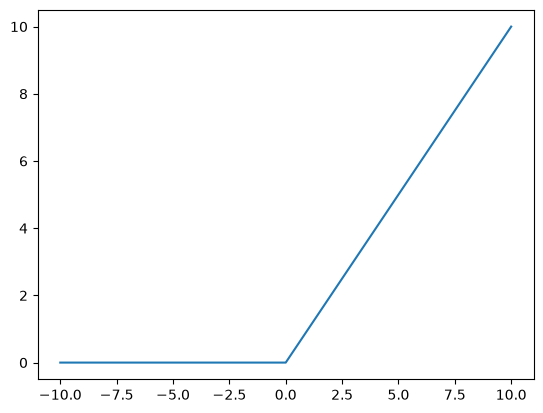

In [3]:
# plot inputs and outputs
from matplotlib import pyplot

# rectified linear function
def rectified(x):
	return max(0.0, x)

# define a series of inputs
series_in = [x for x in range(-10, 11)]
# calculate outputs for our inputs
series_out = [rectified(x) for x in series_in]
# line plot of raw inputs to rectified outputs
pyplot.plot(series_in, series_out)
pyplot.show()

整流线性激活函数的优点：
1、计算简洁性：需要一个max（）函数
2、表征性稀疏性：能够输出真正的零值，这意味着负输入可以输出真正的零值，从而激活神经网络中的隐藏层，其中可能包含一个或多个真正的零值。这被称为稀疏表示，是表征学习中理想的特性，因为它可以加速学习并简化模型。
3、线性行为：使用该激活函数训练的网络几乎完全避免梯度消失的问题，因为梯度与节点激活数保持成正比。


使用整流线激活的技巧：
1、使用ReLU作为默认激活函数
2、用 ReLU 配合 MLP、CNN，但可能不适合 RNN
3、试试更小的偏置输入值：偏置是节点上具有固定值的输入。偏置会改变激活函数，传统上将偏置输入值设为1.0。在网络中使用ReLU时，考虑将偏置设为较小的值，比如0.1。
4、使用“He权重初始化”：He 初始化（也叫 Kaiming 初始化），是专门为 ReLU 网络设计的一组权重初始值，目的是解决深层网络训练不动的根本问题：信号在逐层传播中消失或爆炸。
5、比例输入数据
6、使用重量惩罚：使用权重正则化形式，比如L1或L2向量范数

In [ ]:
# PyTorch｜建立二分类任务的多层感知机模型
from numpy import vstack
from pandas import read_csv
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torch import Tensor
from torch.nn import Linear
from torch.nn import ReLU
from torch.nn import Sigmoid
from torch.nn import Module
from torch.optim import SGD
from torch.nn import BCELoss
from torch.nn.init import kaiming_uniform_
from torch.nn.init import xavier_uniform_

# 数据集定义
class CSVDataset(Dataset):
    # 导入数据
    def __init__(self, path):
        # 导入传入路径的数据集为 Pandas DataFrame 格式
        df = read_csv(path, header=None)
        # 设置神经网络的输入与输出
        self.X = df.values[:, :-1]
        self.y = df.values[:, -1]
        # 确保输入数据是浮点数
        self.X = self.X.astype('float32')
        # 使用浮点型标签编码原输出
        self.y = LabelEncoder().fit_transform(self.y)
        self.y = self.y.astype('float32')
        self.y = self.y.reshape((len(self.y), 1))

    # 定义获得数据集长度的方法
    def __len__(self):
        return len(self.X)

    # 定义获得某一行数据的方法
    def __getitem__(self, idx):
        return [self.X[idx], self.y[idx]]

    # 在类内部定义划分训练集和测试集的方法，在本例中，训练集比例为 0.67，测试集比例为 0.33
    def get_splits(self, n_test=0.33):
        # 确定训练集和测试集的尺寸
        test_size = round(n_test * len(self.X))
        train_size = len(self.X) - test_size
        # 根据尺寸划分训练集和测试集并返回
        return random_split(self, [train_size, test_size])

# 模型定义
class MLP(Module):
    # 定义模型输入
    def __init__(self, n_inputs):
        super(MLP, self).__init__()
        # 输入到隐层 1
        self.hidden1 = Linear(n_inputs, 10)
        kaiming_uniform_(self.hidden1.weight, nonlinearity='relu')
        self.act1 = ReLU()
        # 隐层 2
        self.hidden2 = Linear(10, 8)
        kaiming_uniform_(self.hidden2.weight, nonlinearity='relu')
        self.act2 = ReLU()
        # 隐层 3 和输出
        self.hidden3 = Linear(8, 1)
        xavier_uniform_(self.hidden3.weight)
        self.act3 = Sigmoid()

    # 前向传播
    def forward(self, X):
        # 输入到隐层 1
        X = self.hidden1(X)
        X = self.act1(X)
         # 隐层 2
        X = self.hidden2(X)
        X = self.act2(X)
        # 隐层 3 和输出
        X = self.hidden3(X)
        X = self.act3(X)
        return X

# 准备数据集
def prepare_data(path):
    # 导入数据集
    dataset = CSVDataset(path)
    # 划分训练集和测试集并返回
    train, test = dataset.get_splits()
    # 为训练集和测试集创建 DataLoader
    train_dl = DataLoader(train, batch_size=32, shuffle=True)
    test_dl = DataLoader(test, batch_size=1024, shuffle=False)
    return train_dl, test_dl

# 训练模型
def train_model(train_dl, model):
    # 定义优化器
    criterion = BCELoss()
    optimizer = SGD(model.parameters(), lr=0.01, momentum=0.9)
    # 枚举 epochs
    for epoch in range(100):
        # 枚举 mini batches
        for i, (inputs, targets) in enumerate(train_dl):
            # 梯度清除
            optimizer.zero_grad()
            # 计算模型输出
            yhat = model(inputs)
            # 计算损失
            loss = criterion(yhat, targets)
            # 贡献度分配
            loss.backward()
            # 升级模型权重
            optimizer.step()

# 评估模型
#评估函数的 "流程骨架"（遍历 → 预测 → 收集 → 算指标）
def evaluate_model(test_dl, model):
    predictions, actuals = list(), list()
    for i, (inputs, targets) in enumerate(test_dl):
        # 在测试集上评估模型
        yhat = model(inputs)
        # 转化为 numpy 数据类型
        yhat = yhat.detach().numpy()
        actual = targets.numpy()
        actual = actual.reshape((len(actual), 1))
        # 转化为类值
        yhat = yhat.round()
        # 保存
        predictions.append(yhat)
        actuals.append(actual)
    predictions, actuals = vstack(predictions), vstack(actuals)
    # 计算准确度
    acc = accuracy_score(actuals, predictions)
    return acc

# 对一行数据进行类预测
def predict(row, model):
    # 转换源数据
    row = Tensor([row])
    # 做出预测
    yhat = model(row)
    # 转化为 numpy 数据类型
    yhat = yhat.detach().numpy()
    return yhat

# 准备数据
path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/ionosphere.csv'
train_dl, test_dl = prepare_data(path)
print(len(train_dl.dataset), len(test_dl.dataset))
# 定义网络
model = MLP(34)
# 训练模型
train_model(train_dl, model)
# 评估模型
acc = evaluate_model(test_dl, model)
print('Accuracy: %.3f' % acc)
# 进行单个预测（预期类=1）
row = [1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1,0.03760,0.85243,-0.17755,0.59755,-0.44945,0.60536,-0.38223,0.84356,-0.38542,0.58212,-0.32192,0.56971,-0.29674,0.36946,-0.47357,0.56811,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300]
yhat = predict(row, model)
yhat_val = yhat[0]
print('Predicted: %.3f (class=%d)' % (yhat, yhat.round()))